# Dam Structural Health Monitoring
## VT Crack Quantification ROIs Dataset → CNN → RUL

---

### Dataset structure (Kaggle)
```
/kaggle/input/datasets/vineetbhoir/crack-quantification-rois-dataset/Dataset/
├── Cropped/
│   ├── 0.5/Sample_1/Sample_1_0.5_cropped.JPG
│   ├── 0.75/Sample_1/Sample_1_0.75_cropped.JPG
│   └── 1.0/Sample_1/Sample_1_1.0_cropped.JPG
├── Ground_Truth_Masks/
│   ├── 0.5/Sample_1/Sample_1_0.5_cropped.jpg
│   └── ...
└── ROI_Measurements.csv
```

### Pipeline
```
ROI_Measurements.csv + Ground_Truth_Masks/
        ↓  Section 2  — build labels.csv
        ↓  Section 3  — augment to 450 images
        ↓  Section 4  — split train/val/test
        ↓  Section 5  — CNN (ResNet50) trains on mean_width + max_width
        ↓  Section 6  — inference & evaluation
        ↓  Section 7  — LEFM + Paris Law → K_I/K_IC → RUL
        ↓  Section 8  — dashboard & visualisations
```

## 0 · Imports

In [2]:
import os, math, time, csv, json, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as tvt          # always tvt — never T
from torchvision.transforms import functional as TF
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

C_BLUE, C_GREEN, C_ORANGE, C_RED, C_PURPLE, C_GREY = \
    '#00C8FF', '#39FF14', '#FF6B35', '#FF2D55', '#BF5FFF', '#8E9BB0'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


## 1 · Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path('YOUR PATH')
CSV_PATH     = DATASET_ROOT / 'ROI_Measurements.csv'
IMAGES_DIR   = DATASET_ROOT / 'Cropped'
MASKS_DIR    = DATASET_ROOT / 'Ground_Truth_Masks'
SAVE_DIR     = Path('/kaggle/working/checkpoints')
LABELS_CSV   = SAVE_DIR / 'labels.csv'
BEST_MODEL   = SAVE_DIR / 'best_model.pt'

# ── Verify ────────────────────────────────────────────────────────────────────
all_ok = True
for label, p in [('Dataset root', DATASET_ROOT), ('CSV', CSV_PATH),
                  ('Cropped/',     IMAGES_DIR),   ('Masks/', MASKS_DIR)]:
    ok = p.exists()
    print(f'  {"✓" if ok else "✗ NOT FOUND"}  {label}: {p}')
    if not ok: all_ok = False
if not all_ok:
    raise FileNotFoundError('One or more paths missing — check DATASET_ROOT')

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Training ──────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
EPOCHS      = 80
LR          = 5e-5
PATIENCE    = 20
NUM_WORKERS = 2
RANDOM_SEED = 42

# ── CNN targets ───────────────────────────────────────────────────────────────
TARGET_COLS = ['mean_width_mm', 'max_width_mm']

# ── Dam physics ───────────────────────────────────────────────────────────────
DAM_H   = 100.0
DAM_T   = 12.0
KIC     = 1.0
Y_GEOM  = 1.1
PARIS_C = 1e-12
PARIS_M = 2.5

print('\nConfig loaded ✓')

  ✓  Dataset root: /kaggle/input/datasets/vineetbhoir/crack-quantification-rois-dataset/Dataset
  ✓  CSV: /kaggle/input/datasets/vineetbhoir/crack-quantification-rois-dataset/Dataset/ROI_Measurements.csv
  ✓  Cropped/: /kaggle/input/datasets/vineetbhoir/crack-quantification-rois-dataset/Dataset/Cropped
  ✓  Masks/: /kaggle/input/datasets/vineetbhoir/crack-quantification-rois-dataset/Dataset/Ground_Truth_Masks

Config loaded ✓


## 2 · Build labels.csv

In [4]:
def mask_to_geometry(mask_path: str) -> dict:
    img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return {'length_px': 0, 'orientation_deg': 0.0, 'area_px': 0,
                'avg_width_px': 0.0, 'mask_found': False}
    _, bw = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)
    if bw.max() == 0:
        return {'length_px': 0, 'orientation_deg': 0.0, 'area_px': 0,
                'avg_width_px': 0.0, 'mask_found': True}
    dist = cv2.distanceTransform(bw, cv2.DIST_L2, 5)
    _, skel = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
    skel_px  = int(np.count_nonzero(skel))
    area_px  = int(np.count_nonzero(bw))
    avg_w    = float(area_px / skel_px) if skel_px > 0 else 0.0
    ys, xs   = np.where(bw > 0)
    pts      = np.column_stack([xs, ys]).astype(np.float32)
    orient   = 0.0
    if len(pts) >= 5:
        _, ev  = cv2.PCACompute(pts, mean=np.array([]))
        orient = float(np.degrees(np.arctan2(ev[0, 1], ev[0, 0])))
    return {'length_px': skel_px, 'orientation_deg': round(orient, 2),
            'area_px': area_px, 'avg_width_px': round(avg_w, 3), 'mask_found': True}


def resolution_to_str(r) -> str:
    return str(float(r))   # 0.5→'0.5'  0.75→'0.75'  1.0→'1.0'


def find_image(sample: str, res_str: str) -> Optional[str]:
    for ext in ['.JPG', '.jpg']:
        p = IMAGES_DIR / res_str / sample / f'{sample}_{res_str}_cropped{ext}'
        if p.exists(): return str(p)
    return None


def find_mask(sample: str, res_str: str) -> Optional[str]:
    for ext in ['.jpg', '.JPG', '.png', '.PNG']:
        p = MASKS_DIR / res_str / sample / f'{sample}_{res_str}_cropped{ext}'
        if p.exists(): return str(p)
    return None


roi_df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
roi_df.columns = roi_df.columns.str.strip()

agg = roi_df.groupby(['Sample', 'Resolution'])['Crack Ruler Measurement'].agg(
    mean_width_mm='mean', max_width_mm='max',
    min_width_mm='min',   std_width_mm='std'
).reset_index()

records, missing_imgs, missing_masks = [], [], []

for _, row in agg.iterrows():
    sample  = row['Sample']
    res_str = resolution_to_str(row['Resolution'])
    img_path  = find_image(sample, res_str)
    mask_path = find_mask(sample, res_str)
    if img_path is None:
        missing_imgs.append(f'{sample}_{res_str}'); continue
    if mask_path is None:
        missing_masks.append(f'{sample}_{res_str}')
    geom = mask_to_geometry(mask_path) if mask_path else \
           {'length_px': 0, 'orientation_deg': 0.0, 'area_px': 0,
            'avg_width_px': 0.0, 'mask_found': False}
    records.append({
        'filename':        img_path,
        'sample':          sample,
        'resolution':      float(row['Resolution']),
        'mean_width_mm':   round(float(row['mean_width_mm']), 4),
        'max_width_mm':    round(float(row['max_width_mm']),  4),
        'length_px':       geom['length_px'],
        'orientation_deg': geom['orientation_deg'],
        'area_px':         geom['area_px'],
        'avg_width_px':    geom['avg_width_px'],
        'mask_path':       mask_path or '',
        'mask_found':      geom['mask_found'],
    })

labels_df = pd.DataFrame(records)
labels_df.to_csv(LABELS_CSV, index=False)
print(f'Total rows   : {len(labels_df)}')
print(f'Masks found  : {labels_df["mask_found"].sum()} / {len(labels_df)}')
if missing_imgs:  print(f'Missing images : {missing_imgs}')
if missing_masks: print(f'Missing masks  : {missing_masks}')
print(labels_df[['sample','resolution','mean_width_mm','max_width_mm']].head(6).to_string(index=False))

Total rows   : 45
Masks found  : 45 / 45
   sample  resolution  mean_width_mm  max_width_mm
 Sample_1        0.50           2.29           4.0
 Sample_1        0.75           2.29           4.0
 Sample_1        1.00           2.29           4.0
Sample_10        0.50           1.12           2.1
Sample_10        0.75           1.12           2.1
Sample_10        1.00           1.12           2.1


## 3 · Data Augmentation  (45 → 450 images)

In [5]:
def augment_dataset(df: pd.DataFrame, n_augments: int = 9) -> pd.DataFrame:
    AUG_DIR = Path('/kaggle/working/augmented/images')
    AUG_DIR.mkdir(parents=True, exist_ok=True)

    aug_fns = [
        ('hflip',   lambda img: TF.hflip(img)),
        ('vflip',   lambda img: TF.vflip(img)),
        ('rot90',   lambda img: TF.rotate(img, 90)),
        ('rot180',  lambda img: TF.rotate(img, 180)),
        ('rot270',  lambda img: TF.rotate(img, 270)),
        ('bright-', lambda img: TF.adjust_brightness(img, 0.6)),
        ('bright+', lambda img: TF.adjust_brightness(img, 1.4)),
        ('contr-',  lambda img: TF.adjust_contrast(img, 0.6)),
        ('contr+',  lambda img: TF.adjust_contrast(img, 1.5)),
        ('gamma-',  lambda img: TF.adjust_gamma(img, 0.7)),
        ('gamma+',  lambda img: TF.adjust_gamma(img, 1.3)),
        ('blur',    lambda img: TF.gaussian_blur(img, kernel_size=5)),
        ('sharp',   lambda img: TF.adjust_sharpness(img, 2.0)),
    ]

    orient_adjust = {
        'hflip': lambda o: -o,
        'vflip': lambda o: -o,
        'rot90': lambda o: (o + 90) % 180,
        'rot270':lambda o: (o + 90) % 180,
    }

    new_rows = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in df.iterrows():
        img  = Image.open(row['filename']).convert('RGB')
        base = Path(row['filename']).stem
        chosen = rng.choice(len(aug_fns),
                            size=min(n_augments, len(aug_fns)),
                            replace=False)
        for idx in chosen:
            name, fn = aug_fns[idx]
            aug_img  = fn(img)
            aug_path = AUG_DIR / f'{base}_aug_{name}.jpg'
            aug_img.save(aug_path, quality=95)
            adj = orient_adjust.get(name, lambda o: o)
            new_rows.append({
                'filename':        str(aug_path),
                'sample':          row['sample'],
                'resolution':      row['resolution'],
                'mean_width_mm':   row['mean_width_mm'],
                'max_width_mm':    row['max_width_mm'],
                'length_px':       row['length_px'],
                'orientation_deg': adj(row['orientation_deg']),
                'area_px':         row['area_px'],
                'avg_width_px':    row['avg_width_px'],
                'mask_path':       row['mask_path'],
                'mask_found':      row['mask_found'],
            })

    aug_df   = pd.DataFrame(new_rows)
    combined = pd.concat([df, aug_df], ignore_index=True)
    combined.to_csv(SAVE_DIR / 'labels_augmented.csv', index=False)
    print(f'Original  : {len(df)}')
    print(f'Augmented : {len(aug_df)}')
    print(f'Total     : {len(combined)}')
    return combined


labels_df = augment_dataset(labels_df, n_augments=9)

Original  : 45
Augmented : 405
Total     : 450


## 4 · Split & Label Stats

In [6]:
train_df, temp_df = train_test_split(labels_df, test_size=0.2,
                                     random_state=RANDOM_SEED,
                                     stratify=labels_df['sample'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5,
                                     random_state=RANDOM_SEED,
                                     stratify=temp_df['sample'])

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df)} images')
print(f'Val   : {len(val_df)} images')
print(f'Test  : {len(test_df)} images')

LABEL_STATS = {}
for col in TARGET_COLS:
    LABEL_STATS[col] = {
        'mean': float(train_df[col].mean()),
        'std':  float(train_df[col].std()) + 1e-8,
    }
print('\nLabel stats (from train):')
for k, v in LABEL_STATS.items():
    print(f'  {k}: mean={v["mean"]:.3f}  std={v["std"]:.3f}')

Train : 360 images
Val   : 45 images
Test  : 45 images

Label stats (from train):
  mean_width_mm: mean=2.271  std=0.845
  max_width_mm: mean=4.590  std=2.084


## 5 · Dataset class & DataLoaders

In [7]:
def get_transforms(split: str):
    norm = tvt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if split == 'train':
        return tvt.Compose([
            tvt.Resize((IMG_SIZE + 64, IMG_SIZE + 64)),
            tvt.RandomCrop(IMG_SIZE),
            tvt.RandomHorizontalFlip(0.5),
            tvt.RandomVerticalFlip(0.3),
            tvt.RandomRotation(45),
            tvt.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.08),
            tvt.RandomGrayscale(0.15),
            tvt.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            tvt.ToTensor(),
            norm,
            tvt.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # must be after ToTensor
        ])
    return tvt.Compose([tvt.Resize((IMG_SIZE, IMG_SIZE)), tvt.ToTensor(), norm])


class CrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, split: str = 'train'):
        self.df        = df.reset_index(drop=True)
        self.transform = get_transforms(split)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filename']).convert('RGB')
        img = self.transform(img)
        raw  = torch.tensor([row[c] for c in TARGET_COLS], dtype=torch.float32)
        norm = self._normalise(raw)
        return img, norm, raw, row['filename']

    def _normalise(self, t):
        out = t.clone()
        for i, c in enumerate(TARGET_COLS):
            out[i] = (t[i] - LABEL_STATS[c]['mean']) / LABEL_STATS[c]['std']
        return out

    @staticmethod
    def denormalise(t):
        out = t.clone()
        for i, c in enumerate(TARGET_COLS):
            out[..., i] = t[..., i] * LABEL_STATS[c]['std'] + LABEL_STATS[c]['mean']
        return out


train_ds = CrackDataset(train_df, 'train')
val_ds   = CrackDataset(val_df,   'val')
test_ds  = CrackDataset(test_df,  'test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 23
Val batches   : 3
Test batches  : 3


## 6 · CNN Model

In [8]:
class RegressionHead(nn.Module):
    def __init__(self, in_f=512, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(hidden, 64), nn.GELU(),
            nn.Linear(64, 1), nn.Softplus(),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


class DamCrackCNN(nn.Module):
    """
    ResNet50 backbone → shared layer → 2 heads:
      mean_width_mm  |  max_width_mm
    """
    def __init__(self, pretrained=True):
        super().__init__()
        backbone = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        in_f = backbone.fc.in_features   # 2048
        backbone.fc = nn.Identity()

        # Freeze all except layer3 + layer4
        for p in backbone.parameters():        p.requires_grad = False
        for p in backbone.layer3.parameters(): p.requires_grad = True
        for p in backbone.layer4.parameters(): p.requires_grad = True

        self.backbone        = backbone
        self.shared          = nn.Sequential(
            nn.Linear(in_f, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.5)
        )
        self.head_mean_width = RegressionHead()
        self.head_max_width  = RegressionHead()

    def forward(self, x):
        f = self.shared(self.backbone(x))
        return {
            'mean_width': self.head_mean_width(f),
            'max_width':  self.head_max_width(f),
        }


model     = DamCrackCNN(pretrained=True).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

# Sanity check
imgs_t, _, _, _ = next(iter(train_loader))
with torch.no_grad():
    out = model(imgs_t[:2].to(DEVICE))
print('Output shapes:')
for k, v in out.items(): print(f'  {k}: {v.shape}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Total params    : 24,854,850
Trainable params: 23,409,922
Output shapes:
  mean_width: torch.Size([2])
  max_width: torch.Size([2])


## 7 · Training

In [9]:
class MultiTaskLoss(nn.Module):
    def __init__(self, weights=(1.0, 1.0)):
        super().__init__()
        self.register_buffer('w', torch.tensor(weights))
        self.mse = nn.MSELoss()

    def forward(self, preds: dict, targets: torch.Tensor):
        keys   = ['mean_width', 'max_width']
        losses = torch.stack([self.mse(preds[k], targets[:, i])
                              for i, k in enumerate(keys)])
        return (losses * self.w).sum(), dict(zip(keys, losses.detach().cpu().tolist()))


criterion = MultiTaskLoss().to(DEVICE)   # .to(DEVICE) prevents device mismatch

backbone_params = (list(model.backbone.layer3.parameters()) +
                   list(model.backbone.layer4.parameters()))
head_params     = (list(model.shared.parameters()) +
                   list(model.head_mean_width.parameters()) +
                   list(model.head_max_width.parameters()))

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR},
], weight_decay=1e-3)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=1, eta_min=1e-7
)

scaler = GradScaler() if torch.cuda.is_available() else None
print('Loss / optimiser / scheduler ready ✓')

Loss / optimiser / scheduler ready ✓


In [10]:
def run_epoch(loader, train: bool):
    model.train(train)
    tot_loss = 0.0
    tot_mae  = {'mean_width': 0.0, 'max_width': 0.0}
    n = 0
    for batch in loader:
        imgs_b, lbl_norm, _, _ = batch
        imgs_b   = imgs_b.to(DEVICE)
        lbl_norm = lbl_norm.to(DEVICE)
        with autocast(enabled=(scaler is not None)):
            preds = model(imgs_b)
            loss, _ = criterion(preds, lbl_norm)
        if train:
            optimizer.zero_grad(set_to_none=True)
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        tot_loss += loss.item()
        for i, k in enumerate(['mean_width', 'max_width']):
            tot_mae[k] += (preds[k] - lbl_norm[:, i]).abs().mean().item()
        n += 1
    return tot_loss / max(n, 1), {k: v / max(n, 1) for k, v in tot_mae.items()}


log_path     = SAVE_DIR / 'training_log.csv'
best_val     = float('inf')
patience_cnt = 0

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss',
                             'tr_mean_w', 'tr_max_w',
                             'va_mean_w', 'va_max_w', 'lr', 't_s'])

print(f'Training on {DEVICE}  |  {len(train_ds)} images  |  up to {EPOCHS} epochs\n')
print(f'{"Ep":>4}  {"TrainLoss":>10}  {"ValLoss":>10}  '
      f'{"mW-MAE":>8}  {"xW-MAE":>8}  {"LR":>9}')
print('─' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_mae = run_epoch(train_loader, train=True)
    scheduler.step()
    with torch.no_grad():
        va_loss, va_mae = run_epoch(val_loader, train=False)
    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[-1]['lr']

    print(f'{epoch:4d}  {tr_loss:10.4f}  {va_loss:10.4f}  '
          f'{va_mae["mean_width"]:8.4f}  {va_mae["max_width"]:8.4f}  {lr_now:9.2e}')

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch, tr_loss, va_loss,
            tr_mae['mean_width'], tr_mae['max_width'],
            va_mae['mean_width'], va_mae['max_width'],
            lr_now, round(elapsed, 2)
        ])

    if va_loss < best_val:
        best_val, patience_cnt = va_loss, 0
        torch.save({'epoch': epoch, 'state_dict': model.state_dict(),
                    'val_loss': va_loss, 'label_stats': LABEL_STATS}, BEST_MODEL)
        print(f'  ✓ Best model saved  (val={va_loss:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\nDone.  Best val loss = {best_val:.4f}')

Training on cuda  |  360 images  |  up to 80 epochs

  Ep   TrainLoss     ValLoss    mW-MAE    xW-MAE         LR
─────────────────────────────────────────────────────────────────
   1      2.7209      2.4182    0.8334    0.9031   4.97e-05
  ✓ Best model saved  (val=2.4182)
   2      2.3123      2.1795    0.7767    0.8580   4.88e-05
  ✓ Best model saved  (val=2.1795)
   3      2.1362      2.0678    0.7551    0.8373   4.73e-05
  ✓ Best model saved  (val=2.0678)
   4      2.0876      2.0409    0.7454    0.8344   4.52e-05
  ✓ Best model saved  (val=2.0409)
   5      2.0496      2.0098    0.7381    0.8295   4.27e-05
  ✓ Best model saved  (val=2.0098)
   6      2.0113      1.9965    0.7335    0.8275   3.97e-05
  ✓ Best model saved  (val=1.9965)
   7      2.0266      1.9883    0.7316    0.8258   3.64e-05
  ✓ Best model saved  (val=1.9883)
   8      2.0266      1.9803    0.7288    0.8248   3.28e-05
  ✓ Best model saved  (val=1.9803)
   9      1.9955      1.9625    0.7233    0.8231   2.90e-05
 

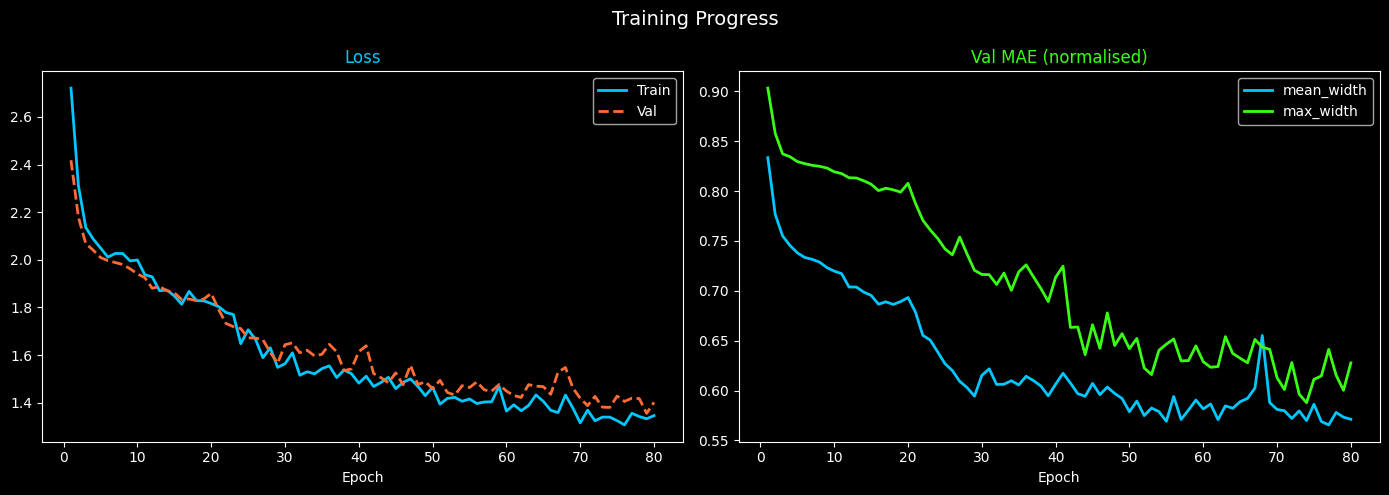

In [11]:
# ── Training curves ───────────────────────────────────────────────────────────
df_log = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Progress', color='white', fontsize=14)

axes[0].plot(df_log['epoch'], df_log['train_loss'], color=C_BLUE,   lw=2, label='Train')
axes[0].plot(df_log['epoch'], df_log['val_loss'],   color=C_ORANGE, lw=2, linestyle='--', label='Val')
axes[0].set_title('Loss', color=C_BLUE); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(df_log['epoch'], df_log['va_mean_w'], color=C_BLUE,  lw=2, label='mean_width')
axes[1].plot(df_log['epoch'], df_log['va_max_w'],  color=C_GREEN, lw=2, label='max_width')
axes[1].set_title('Val MAE (normalised)', color=C_GREEN)
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Inference & Evaluation

In [12]:
# ── Load best model ───────────────────────────────────────────────────────────
ckpt = torch.load(BEST_MODEL, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
LABEL_STATS = ckpt.get('label_stats', LABEL_STATS)
model.eval()
print(f'Loaded epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

INFER_TF = tvt.Compose([
    tvt.Resize((IMG_SIZE, IMG_SIZE)),
    tvt.ToTensor(),
    tvt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def predict(img_path: str) -> dict:
    """
    Returns crack dimensions by combining:
      - CNN prediction  → mean_width_mm, max_width_mm
      - Mask CV         → length_px, orientation_deg  (if mask exists)
    """
    # ── CNN: width prediction ─────────────────────────────────────────────────
    pil  = Image.open(img_path).convert('RGB')
    tens = INFER_TF(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        raw = model(tens)
    result = {}
    for model_key, col in [('mean_width', 'mean_width_mm'), ('max_width', 'max_width_mm')]:
        val = raw[model_key].item() * LABEL_STATS[col]['std'] + LABEL_STATS[col]['mean']
        result[col] = round(float(val), 4)

    # ── Mask CV: length + orientation ─────────────────────────────────────────
    # Try to find the corresponding mask for this image
    img_path_obj = Path(img_path)
    name   = img_path_obj.stem          # e.g. Sample_1_0.5_cropped
    parts  = name.split('_')            # ['Sample', '1', '0.5', 'cropped']

    mask_path = None
    if len(parts) >= 3:
        sample  = f'Sample_{parts[1]}'     # Sample_1
        res_str = parts[2]                 # 0.5
        mask_path = find_mask(sample, res_str)

    if mask_path:
        geom = mask_to_geometry(mask_path)
        result['length_px']       = geom['length_px']
        result['orientation_deg'] = geom['orientation_deg']
    else:
        # Augmented image — derive from original sample row in labels_df
        fname = img_path_obj.name
        match = labels_df[labels_df['filename'].apply(
                    lambda x: Path(x).stem in fname or fname in Path(x).stem)]
        if len(match) > 0 and match.iloc[0]['mask_found']:
            geom = mask_to_geometry(match.iloc[0]['mask_path'])
            result['length_px']       = geom['length_px']
            result['orientation_deg'] = geom['orientation_deg']
        else:
            result['length_px']       = 0
            result['orientation_deg'] = 0.0

    return result

Loaded epoch=79  val_loss=1.3550


In [13]:
# ── Test set metrics ──────────────────────────────────────────────────────────
PREDS_ARR, TRUES_ARR, fnames = [], [], []

for _, row in test_df.iterrows():
    pred = predict(row['filename'])
    PREDS_ARR.append([pred[c] for c in TARGET_COLS])
    TRUES_ARR.append([row[c]  for c in TARGET_COLS])
    fnames.append(row['filename'])

PREDS_ARR = np.array(PREDS_ARR)
TRUES_ARR = np.array(TRUES_ARR)
mae_per   = np.abs(PREDS_ARR - TRUES_ARR).mean(axis=0)
rmse_per  = np.sqrt(((PREDS_ARR - TRUES_ARR) ** 2).mean(axis=0))

print(f'Test set metrics  ({len(test_df)} images):')
print(f'{"Target":<22} {"MAE":>10} {"RMSE":>10}  Unit')
print('─' * 50)
for c, mae, rmse in zip(TARGET_COLS, mae_per, rmse_per):
    print(f'{c:<22} {mae:10.4f} {rmse:10.4f}  mm')

Test set metrics  (45 images):
Target                        MAE       RMSE  Unit
──────────────────────────────────────────────────
mean_width_mm              0.4805     0.7176  mm
max_width_mm               1.2656     1.6321  mm


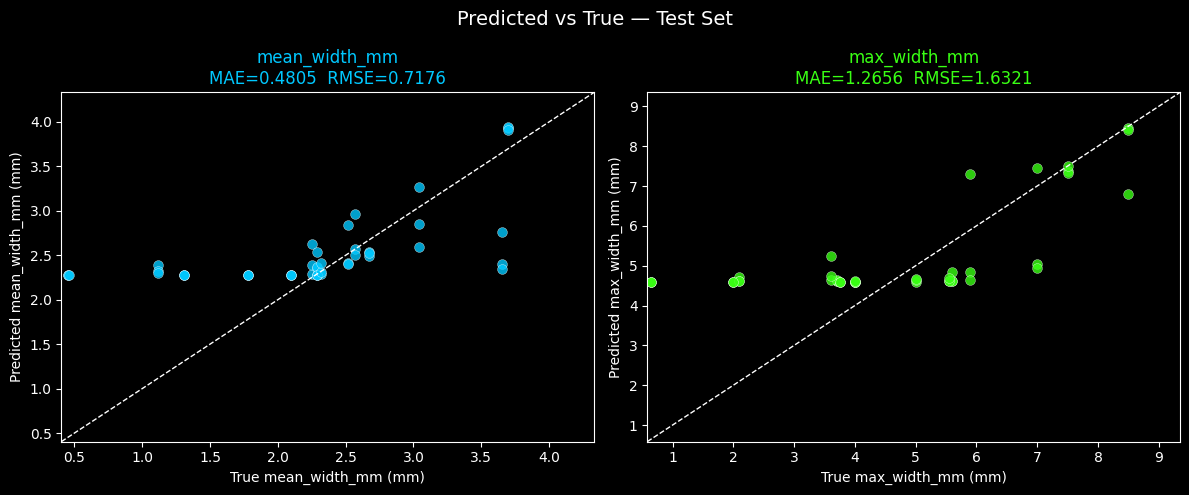

In [14]:
# ── Predicted vs True scatter ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Predicted vs True — Test Set', color='white', fontsize=14)

for ax, c, clr in zip(axes, TARGET_COLS, [C_BLUE, C_GREEN]):
    idx = TARGET_COLS.index(c)
    tr  = TRUES_ARR[:, idx]
    pr  = PREDS_ARR[:, idx]
    lim = [min(tr.min(), pr.min()) * 0.9, max(tr.max(), pr.max()) * 1.1]
    ax.scatter(tr, pr, color=clr, alpha=0.8, s=50, edgecolors='white', lw=0.3)
    ax.plot(lim, lim, 'w--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'True {c} (mm)')
    ax.set_ylabel(f'Predicted {c} (mm)')
    ax.set_title(f'{c}\nMAE={mae_per[idx]:.4f}  RMSE={rmse_per[idx]:.4f}', color=clr)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/pred_vs_true.png', dpi=120, bbox_inches='tight')
plt.show()

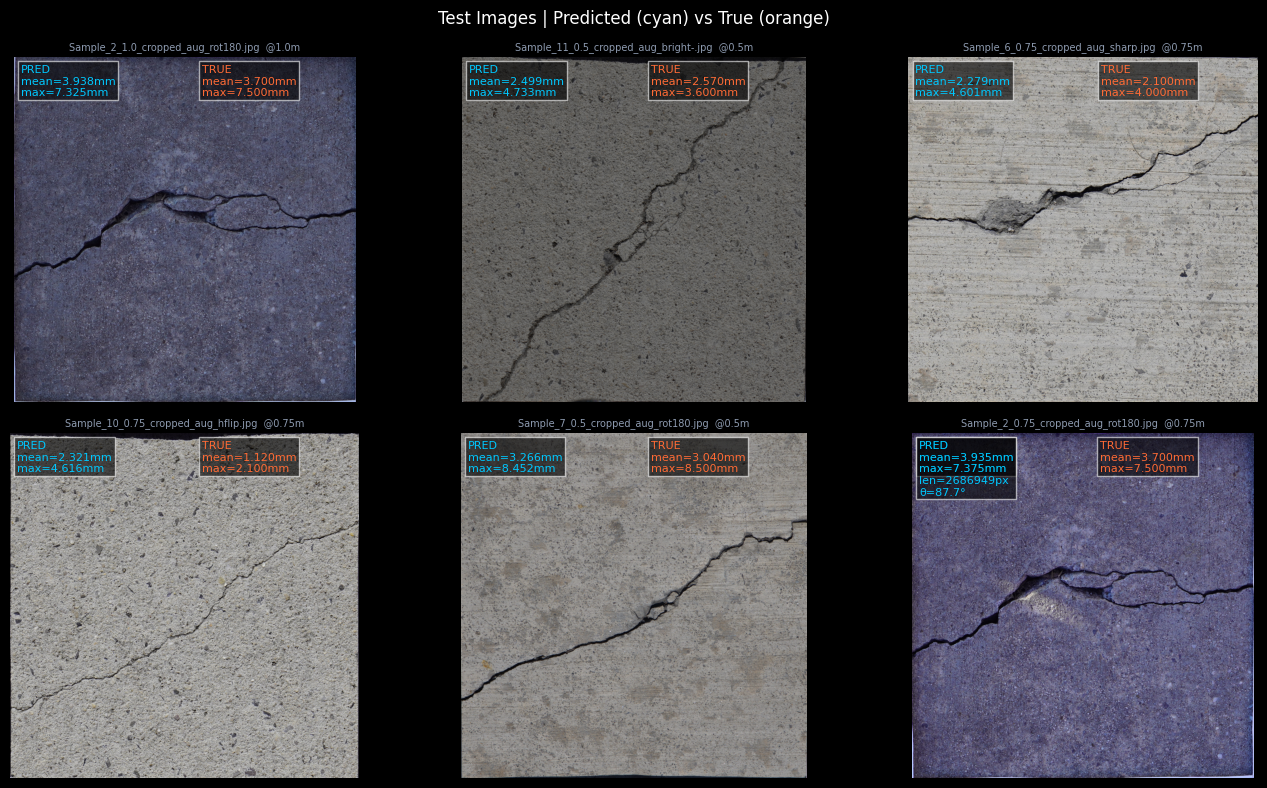

In [15]:
# ── Visual inspection ─────────────────────────────────────────────────────────
n_show = min(6, len(test_df))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Test Images | Predicted (cyan) vs True (orange)', color='white', fontsize=12)

for ax, (_, row) in zip(axes.flat, test_df.sample(n_show, random_state=0).iterrows()):
    pred = predict(row['filename'])
    ax.imshow(np.array(Image.open(row['filename']).convert('RGB')))
    ax.text(0.02, 0.98,
            f"PRED\nmean={pred['mean_width_mm']:.3f}mm\nmax={pred['max_width_mm']:.3f}mm",
            transform=ax.transAxes, va='top', fontsize=8, color=C_BLUE,
            bbox=dict(fc='black', alpha=0.6, pad=2))
    ax.text(0.55, 0.98,
            f"TRUE\nmean={row['mean_width_mm']:.3f}mm\nmax={row['max_width_mm']:.3f}mm",
            transform=ax.transAxes, va='top', fontsize=8, color=C_ORANGE,
            bbox=dict(fc='black', alpha=0.6, pad=2))
    ax.set_title(f"{Path(row['filename']).name}  @{row['resolution']}m", fontsize=7, color=C_GREY)
    ax.axis('off')

ax.text(0.02, 0.98,
        f"PRED\nmean={pred['mean_width_mm']:.3f}mm\n"
        f"max={pred['max_width_mm']:.3f}mm\n"
        f"len={pred['length_px']}px\nθ={pred['orientation_deg']:.1f}°",
        transform=ax.transAxes, va='top', fontsize=8, color=C_BLUE,
        bbox=dict(fc='black', alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/visual_inspection.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 · Fracture Mechanics & RUL Engine

$$p(y)=\rho g y \;\rightarrow\; \sigma=p/t \;\rightarrow\; \sigma_n=\sigma\cos^2\theta$$
$$K_I = Y\,\sigma_n\sqrt{\pi a} \quad [\text{MPa}\cdot\sqrt{\text{m}}]$$
$$\frac{da}{dt}=C(K_I)^m \;\rightarrow\; \text{RUL}=\sum\Delta t \text{ until } K_I\geq K_{IC}$$

Crack depth `a` = `max_width_mm` converted to metres (most conservative measurable dimension).

In [16]:
@dataclass
class DamParams:
    H: float = DAM_H;   t: float = DAM_T
    rho: float = 1000.0; g: float = 9.81
    KIC: float = KIC;   Y: float = Y_GEOM
    C: float = PARIS_C; m: float = PARIS_M
    a_critical: Optional[float] = None


@dataclass
class RULResult:
    rul_years:      float
    rul_capped:     bool
    current_KI:     float
    ratio_KI_KIC:   float
    a_initial_mm:   float
    a_critical_mm:  float
    sigma_n_MPa:    float
    risk_level:     str
    growth_history: list = field(default_factory=list)


class RULEngine:
    SPY = 365.25 * 24 * 3600

    def __init__(self, dam: DamParams, dt_s=86400.0,
                 max_years=50000.0, store_every=365):
        self.dam         = dam
        self.dt          = dt_s
        self.max_steps   = int(max_years * self.SPY / dt_s)
        self.store_every = store_every

    def compute(self, pred: dict) -> RULResult:
        dam   = self.dam
        a_mm  = max(pred.get('max_width_mm', 1.0), 0.01)
        a     = a_mm / 1000.0
        theta = pred.get('orientation_deg', 0.0)          # conservative: assume horizontal crack
        y     = dam.H * 0.4   # conservative water depth

        p       = dam.rho * dam.g * y
        sigma_n = (p / dam.t) * math.cos(math.radians(theta)) ** 2
        s_MPa   = sigma_n / 1e6

        KI0    = dam.Y * s_MPa * math.sqrt(math.pi * a)
        a_crit = (dam.KIC / (dam.Y * s_MPa)) ** 2 / math.pi if s_MPa > 0 \
                 else float('inf')
        if dam.a_critical: a_crit = dam.a_critical

        ratio = KI0 / dam.KIC
        risk  = self._risk(ratio)

        if a >= a_crit or KI0 >= dam.KIC:
            return RULResult(0.0, False, round(KI0,6), round(ratio,6),
                             round(a*1000,4), round(a_crit*1000,4),
                             round(s_MPa,6), 'CRITICAL — Immediate action')

        a_cur, t_s, step = a, 0.0, 0
        hist, capped = [], False
        while a_cur < a_crit and step < self.max_steps:
            KI    = dam.Y * s_MPa * math.sqrt(math.pi * a_cur)
            a_cur += dam.C * (KI ** dam.m) * self.dt
            t_s   += self.dt; step += 1
            if self.store_every > 0 and step % self.store_every == 0:
                hist.append((round(t_s/self.SPY,3), round(a_cur*1000,5), round(KI,7)))
        if step >= self.max_steps: capped = True

        return RULResult(
            rul_years     = round(t_s / self.SPY, 3),
            rul_capped    = capped,
            current_KI    = round(KI0, 6),
            ratio_KI_KIC  = round(ratio, 6),
            a_initial_mm  = round(a * 1000, 4),
            a_critical_mm = round(a_crit * 1000, 4),
            sigma_n_MPa   = round(s_MPa, 6),
            risk_level    = risk,
            growth_history= hist,
        )

    @staticmethod
    def _risk(r):
        if r >= 1.0: return 'CRITICAL — Immediate action'
        if r >= 0.8: return 'HIGH — Urgent inspection'
        if r >= 0.6: return 'MODERATE — Close monitoring'
        if r >= 0.4: return 'ELEVATED — Routine monitoring'
        return               'LOW — Normal operation'


engine = RULEngine(DamParams(), dt_s=86400, max_years=50000, store_every=365)
print('RUL engine ready ✓')

# Quick demo
demo = {'mean_width_mm': 2.29, 'max_width_mm': 4.0}
r    = engine.compute(demo)
print(f'Demo → K_I={r.current_KI:.5f} MPa√m  ratio={r.ratio_KI_KIC:.5f}  Risk: {r.risk_level}')
print(f'       RUL: {">50,000" if r.rul_capped else r.rul_years} years')

RUL engine ready ✓
Demo → K_I=0.00403 MPa√m  ratio=0.00403  Risk: LOW — Normal operation
       RUL: >50,000 years


In [17]:
# ── RUL for all test images ───────────────────────────────────────────────────
rul_records = []
for _, row in test_df.iterrows():
    pred = predict(row['filename'])
    res  = engine.compute(pred)
    rul_records.append({
        'filename':    Path(row['filename']).name,
        'sample':      row['sample'],
        'resolution':  row['resolution'],
        'pred_mean_w': pred['mean_width_mm'],
        'pred_max_w':  pred['max_width_mm'],
        'true_mean_w': row['mean_width_mm'],
        'true_max_w':  row['max_width_mm'],
        'KI_MPa':      res.current_KI,
        'KI_KIC':      res.ratio_KI_KIC,
        'sigma_n_MPa': res.sigma_n_MPa,
        'a_crit_mm':   res.a_critical_mm,
        'RUL_yr':      res.rul_years,
        'RUL_capped':  res.rul_capped,
        'risk':        res.risk_level,
    })

df_rul = pd.DataFrame(rul_records)
df_rul.to_csv(SAVE_DIR / 'rul_results.csv', index=False)
print(df_rul[['filename','pred_max_w','KI_KIC','RUL_yr','RUL_capped','risk']].to_string(index=False))

                              filename  pred_max_w   KI_KIC  RUL_yr  RUL_capped                   risk
              Sample_8_1.0_cropped.JPG      4.6157 0.004323 50000.0        True LOW — Normal operation
  Sample_14_0.5_cropped_aug_contr-.jpg      4.6018 0.000614 50000.0        True LOW — Normal operation
  Sample_1_0.75_cropped_aug_gamma-.jpg      4.5992 0.000009 50000.0        True LOW — Normal operation
   Sample_10_1.0_cropped_aug_hflip.jpg      4.7191 0.000090 50000.0        True LOW — Normal operation
  Sample_10_0.75_cropped_aug_hflip.jpg      4.6160 0.004287 50000.0        True LOW — Normal operation
   Sample_14_0.5_cropped_aug_vflip.jpg      4.6339 0.000616 50000.0        True LOW — Normal operation
    Sample_3_1.0_cropped_aug_rot90.jpg      4.5985 0.000000 50000.0        True LOW — Normal operation
   Sample_13_1.0_cropped_aug_vflip.jpg      4.6096 0.004190 50000.0        True LOW — Normal operation
  Sample_15_1.0_cropped_aug_contr+.jpg      5.0372 0.001139 50000.0      

## 10 · Dashboard

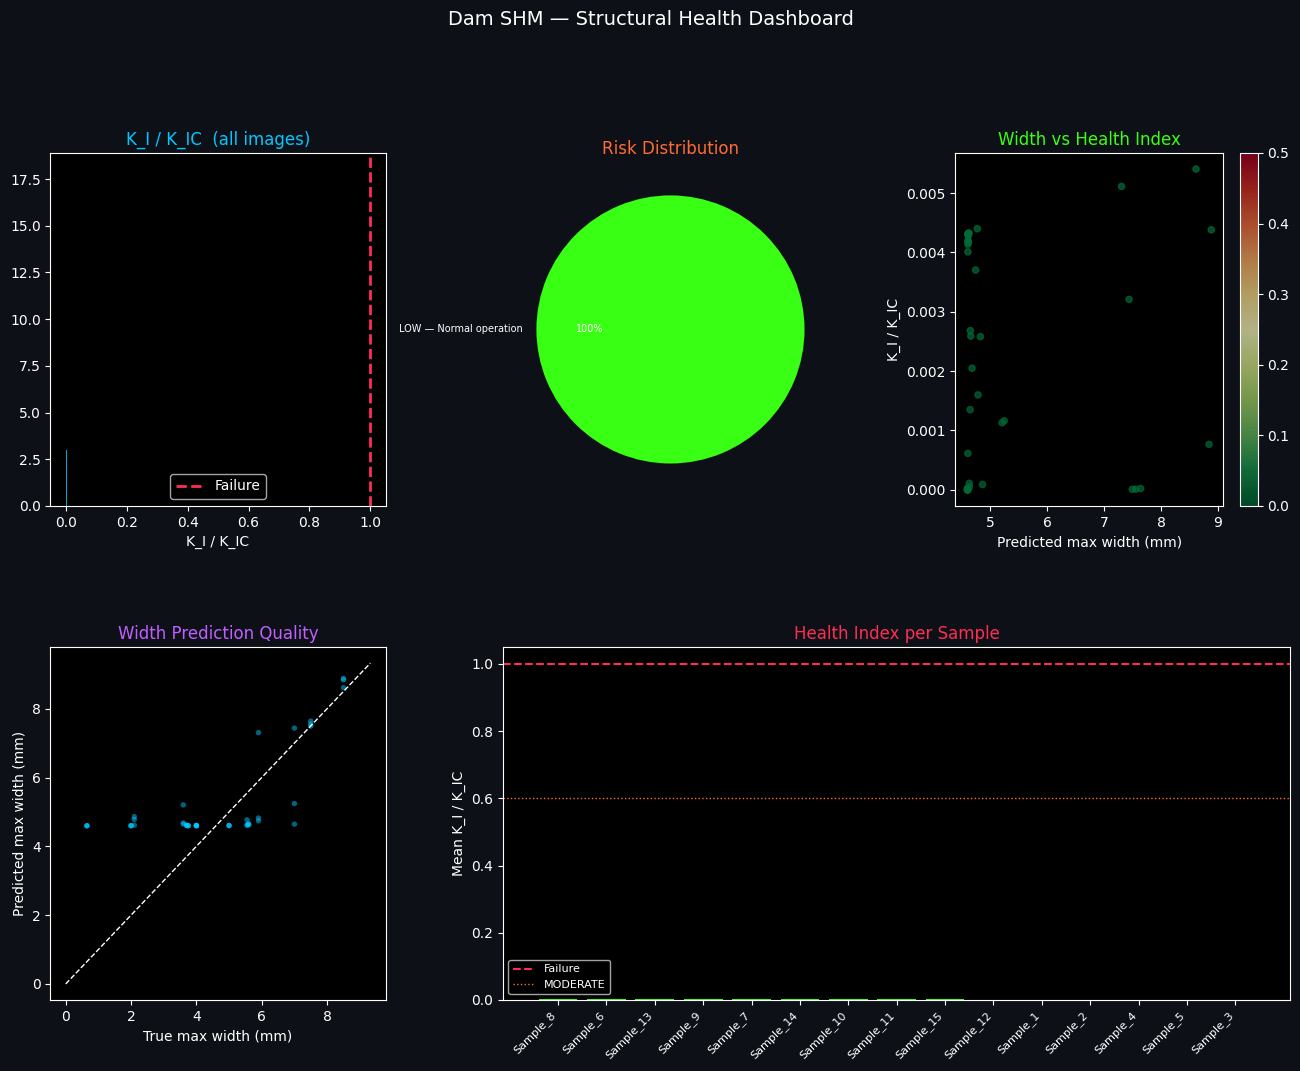

In [33]:
# ── Compute RUL for all 450 images ────────────────────────────────────────────
# Only use original 45 images, not augmented ones
originals_df = labels_df[~labels_df['filename'].str.contains('aug')].reset_index(drop=True)

all_rul = []
for _, row in originals_df.iterrows():
    pred = predict(row['filename'])
    res  = engine.compute(pred)
    all_rul.append({
        'sample':     row['sample'],
        'resolution': row['resolution'],
        'pred_max_w': pred['max_width_mm'],
        'true_max_w': row['max_width_mm'],
        'KI_KIC':     res.ratio_KI_KIC,
        'RUL_yr':     res.rul_years,
        'RUL_capped': res.rul_capped,
        'risk':       res.risk_level,
    })
df_all = pd.DataFrame(all_rul)

risk_clr = {
    'LOW — Normal operation':        C_GREEN,
    'ELEVATED — Routine monitoring': '#AAFF00',
    'MODERATE — Close monitoring':   C_ORANGE,
    'HIGH — Urgent inspection':      '#FF8800',
    'CRITICAL — Immediate action':   C_RED,
}

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#0D1117')
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

# 1 — K_I/K_IC histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_all['KI_KIC'], bins=20, color=C_BLUE, alpha=0.85, edgecolor='none')
ax1.axvline(1.0, color=C_RED, lw=2, linestyle='--', label='Failure')
ax1.set_title('K_I / K_IC  (all images)', color=C_BLUE)
ax1.set_xlabel('K_I / K_IC'); ax1.legend()

# 2 — Risk pie
ax2 = fig.add_subplot(gs[0, 1])
rc  = df_all['risk'].value_counts()
ax2.pie(rc.values, labels=rc.index,
        colors=[risk_clr.get(r, C_GREY) for r in rc.index],
        autopct='%1.0f%%', textprops={'fontsize': 7, 'color': 'white'})
ax2.set_title('Risk Distribution', color=C_ORANGE)

# 3 — K_I/K_IC vs predicted width
ax3 = fig.add_subplot(gs[0, 2])
sc  = ax3.scatter(df_all['pred_max_w'], df_all['KI_KIC'],
                  c=df_all['KI_KIC'], cmap='RdYlGn_r',
                  vmin=0, vmax=0.5, s=20, alpha=0.7)
ax3.set_xlabel('Predicted max width (mm)'); ax3.set_ylabel('K_I / K_IC')
ax3.set_title('Width vs Health Index', color=C_GREEN)
plt.colorbar(sc, ax=ax3)

# 4 — Pred vs True width (all images)
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(df_all['true_max_w'], df_all['pred_max_w'],
            color=C_BLUE, alpha=0.5, s=15, edgecolors='none')
lim = [0, df_all[['true_max_w','pred_max_w']].values.max() * 1.05]
ax4.plot(lim, lim, 'w--', lw=1)
ax4.set_xlabel('True max width (mm)'); ax4.set_ylabel('Predicted max width (mm)')
ax4.set_title('Width Prediction Quality', color=C_PURPLE)

# 5 — Health index per sample
ax5 = fig.add_subplot(gs[1, 1:])
per_sample = df_all.groupby('sample')['KI_KIC'].mean().sort_values(ascending=False)
bc = [risk_clr.get(engine._risk(v), C_GREY) for v in per_sample.values]
ax5.bar(per_sample.index, per_sample.values, color=bc, edgecolor='none')
ax5.axhline(1.0, color=C_RED,    lw=1.5, linestyle='--', label='Failure')
ax5.axhline(0.6, color=C_ORANGE, lw=1.0, linestyle=':',  label='MODERATE')
ax5.set_xticklabels(per_sample.index, rotation=45, ha='right', fontsize=8)
ax5.set_ylabel('Mean K_I / K_IC')
ax5.set_title('Health Index per Sample', color=C_RED); ax5.legend(fontsize=8)

plt.suptitle('Dam SHM — Structural Health Dashboard', fontsize=14, color='white', y=1.01)
plt.savefig(f'{SAVE_DIR}/dashboard.png', dpi=130, bbox_inches='tight', facecolor='#0D1117')
plt.show()

## 11 · Single-image Inspection

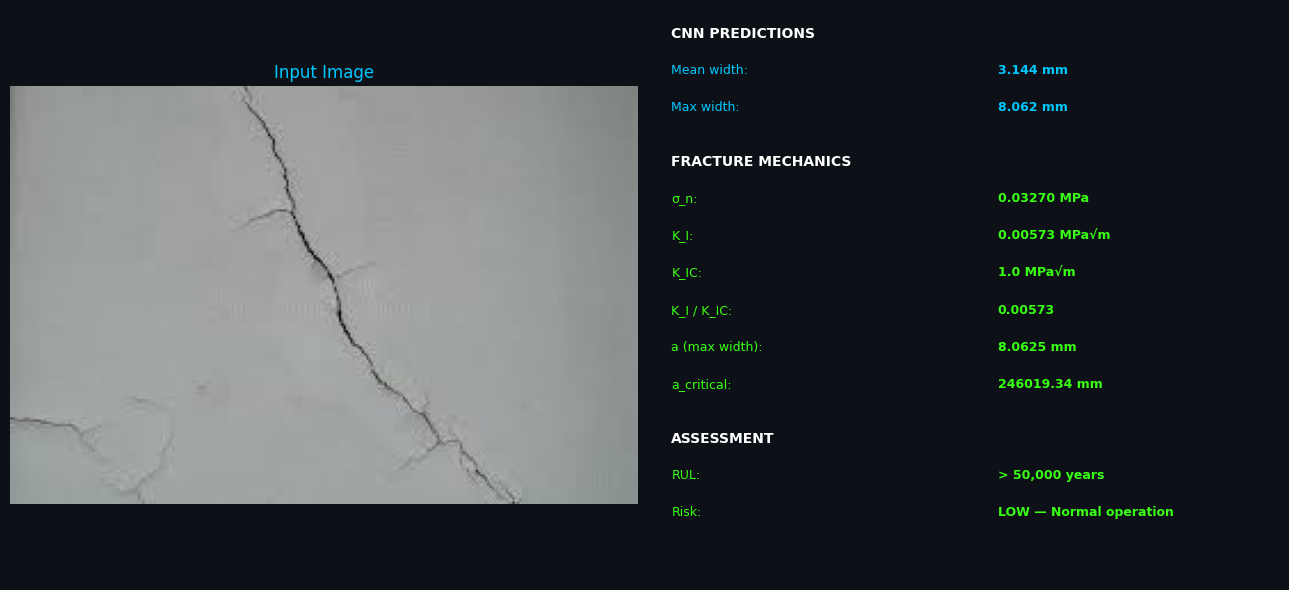

Saved → /kaggle/working/checkpoints/inspection_report.png


In [45]:
# ── Change this path to inspect any new crack photo ───────────────────────────

risk_clr = {
    'LOW — Normal operation':        C_GREEN,
    'ELEVATED — Routine monitoring': '#AAFF00',
    'MODERATE — Close monitoring':   C_ORANGE,
    'HIGH — Urgent inspection':      '#FF8800',
    'CRITICAL — Immediate action':   C_RED,
}

IMAGE_PATH =  'SET YOUR PATH'   # default: first test image

pred    = predict(IMAGE_PATH)
rul_res = engine.compute(pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#0D1117')

axes[0].imshow(Image.open(IMAGE_PATH))
axes[0].set_title('Input Image', color=C_BLUE); axes[0].axis('off')

axes[1].set_facecolor('#0D1117'); axes[1].axis('off')
rc = risk_clr.get(rul_res.risk_level, C_GREY)
lines = [
    ('CNN PREDICTIONS', '',                                        'white', True),
    ('Mean width',      f"{pred['mean_width_mm']:.3f} mm",        C_BLUE,  False),
    ('Max width',       f"{pred['max_width_mm']:.3f} mm",         C_BLUE,  False),
    ('', '', '', False),
    ('FRACTURE MECHANICS', '',                                     'white', True),
    ('σ_n',             f"{rul_res.sigma_n_MPa:.5f} MPa",         C_GREEN, False),
    ('K_I',             f"{rul_res.current_KI:.5f} MPa√m",        C_GREEN, False),
    ('K_IC',            f"{KIC} MPa√m",                           C_GREEN, False),
    ('K_I / K_IC',      f"{rul_res.ratio_KI_KIC:.5f}",            C_GREEN, False),
    ('a (max width)',   f"{rul_res.a_initial_mm:.4f} mm",          C_GREEN, False),
    ('a_critical',      f"{rul_res.a_critical_mm:.2f} mm",         C_GREEN, False),
    ('', '', '', False),
    ('ASSESSMENT', '',                                             'white', True),
    ('RUL',  f"{'> 50,000' if rul_res.rul_capped else rul_res.rul_years} years", rc, False),
    ('Risk', rul_res.risk_level,                                   rc,      False),
]
y = 0.97
for label, value, clr, bold in lines:
    if label == '': y -= 0.03; continue
    fw = 'bold' if bold else 'normal'
    axes[1].text(0.03, y, label + ('' if bold else ':'),
                 transform=axes[1].transAxes, va='top',
                 fontsize=10 if bold else 9, color=clr, fontweight=fw)
    if value:
        axes[1].text(0.55, y, value, transform=axes[1].transAxes,
                     va='top', fontsize=9, color=clr, fontweight='bold')
    y -= 0.065

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/inspection_report.png', dpi=130, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print(f'Saved → {SAVE_DIR}/inspection_report.png')